# 04 — L-BFGS vs Structure-Based QR

We compare the **existing implementations** of L-BFGS and structure-based
Householder QR on the same regularized least-squares problems. The experiments
measure numerical accuracy, convergence, complete solution time, sensitivity to
regularization, scaling with both dimensions, and theoretical storage.

Shared settings and helper functions are defined in [lib/comparison.py](lib/comparison.py)
and imported in the next cell. They control the solver options, repetitions,
parameter sweeps, and accuracy targets used throughout the notebook.
As in the preceding notebooks, $X\in\mathbb R^{m\times n}$ and $w\in\mathbb R^m$.
The L-BFGS history length is denoted by $h$, to distinguish it from $m$.

We use `float64`, fixed random seeds, and one BLAS thread when `threadpoolctl`
is available. Timings remain specific to this machine and these Python/NumPy
implementations. The following cell imports the project routines and shared
settings, configures the plots, and displays the numerical environment.
It supports execution from either `src/` or its parent.

In [92]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Locate the project without depending on the notebook's launch directory
SRC_DIR = Path.cwd() if (Path.cwd() / 'lib').is_dir() else Path.cwd() / 'src'
if not (SRC_DIR / 'lib').is_dir():
    raise FileNotFoundError('Run the notebook from the project directory or src/.')
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from lib.lbfgs import lbfgs_optimize
from lib.utils import build_augmented_X, compute_gradient, load_ml_cup
from lib.utils import positive
# Import shared experiment settings and comparison helpers
from lib.comparison import *

# Set up plotting and DataFrame display options
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})
pd.set_option('display.float_format', lambda value: f'{value:.3e}')
pd.set_option('display.max_columns', 20)

# Report the runtime environment and active BLAS thread limit
print(f'Python {platform.python_version()} | NumPy {np.__version__} | {platform.machine()}')
print(f'{REPEATS} measured runs per configuration, after one warm-up per method.')
print('L-BFGS settings:', LBFGS_OPTIONS)
if threadpool_info is None:
    print('threadpoolctl unavailable: timings use the environment\'s BLAS settings.')
else:
    with blas_context():
        display(pd.DataFrame([
            {key: pool.get(key) for key in ('internal_api', 'version', 'num_threads')}
            for pool in threadpool_info() if pool['user_api'] == 'blas'
        ]))

Python 3.13.9 | NumPy 2.1.3 | arm64
10 measured runs per configuration, after one warm-up per method.
L-BFGS settings: {'m_history': 10, 'max_iter': 2000, 'tol': 1e-10, 'tol_type': 'relative', 'line_search': 'exact', 'h0_scaling': 'bb1', 'use_restart': True, 'verbose': False}


,internal_api,version,num_threads
0,openblas,0.3.29,1


## 1. Common mathematical problem and data

Both algorithms minimize
$$
f(w)=\frac12\|X^Tw-y\|_2^2+\frac{\lambda^2}{2}\|w\|_2^2
     =\frac12\|Aw-b\|_2^2,
\qquad A=\begin{bmatrix}X^T\\\lambda I_m\end{bmatrix},
\quad b=\begin{bmatrix}y\\0\end{bmatrix}.
$$
For $\lambda>0$, $H=XX^T+\lambda^2I_m$ is positive definite, so the minimizer
is unique. L-BFGS uses $g(w)=X(X^Tw-y)+\lambda^2w$ and exact line search
$$
\alpha_k=-\frac{g_k^Tp_k}{\|X^Tp_k\|_2^2+\lambda^2\|p_k\|_2^2}.
$$
QR factors the row-permuted system $[\lambda I_m;X^T]$ with compact
Householder reflectors and solves an upper-triangular system.

The following cell loads the same standardized ML-CUP matrix as the other
notebooks. **The loader generates a synthetic vector $y\in\mathbb R^n$**;
the experiments concern numerical solution accuracy, not supervised prediction
accuracy or generalization. All primary L-BFGS runs start at $w_0=0$.

In [93]:
DATA_PATH = SRC_DIR / 'dataset' / 'ML-CUP25-TR.csv'

# Load the standardized data and deterministic synthetic right-hand side
X, y, m, n = load_ml_cup(DATA_PATH, seed=SEED)
X = np.asarray(X, dtype=np.float64)
y = np.asarray(y, dtype=np.float64)

# Check input dimensions and finite values before running the experiments
assert X.shape == (m, n) and y.shape == (n,)
assert np.isfinite(X).all() and np.isfinite(y).all()
assert LAMBDA > 0 and REPEATS >= 3

print(f'X: {X.shape}; y: {y.shape}; unknowns: {m}; lambda: {LAMBDA}')
print(f'Initial objective f(0) = {0.5 * np.dot(y, y):.6e}')

X: (500, 12); y: (12,); unknowns: 500; lambda: 0.5
Initial objective f(0) = 3.571959e+00


## 2. Independent SVD reference and conditioning

For the thin SVD $X=U\Sigma V^T$, the regularized minimizer is
$$
w_{\mathrm{ref}}=U\,\operatorname{diag}
\left(\frac{\sigma_i}{\sigma_i^2+\lambda^2}\right)V^Ty.
$$
This floating-point reference avoids forming $XX^T$; it is not an exact
arithmetic oracle. Its gradient is checked below. Reference construction is
excluded from every solver timing. We do not use the normal-equations routine
`solve_exact` as ground truth because forming $A^TA$ squares conditioning.

Let $\sigma_{\min,\mathrm{full}}=0$ if $m>n$, and otherwise use the smallest
singular value returned by the SVD. Then
$$
\kappa_2(A)=\frac{\sqrt{\sigma_{\max}^2+\lambda^2}}
                  {\sqrt{\sigma_{\min,\mathrm{full}}^2+\lambda^2}},
\qquad \kappa_2(H)=\kappa_2(A)^2.
$$
The next cell computes the thin SVD and passes its factors to
`svd_solver_baseline` from `lib/comparison.py`. The returned `svd_baseline`
dictionary contains the solution, objective, norms, and condition numbers.
The SVD factors are reused when only $\lambda$ changes, and the relative
gradient verifies the baseline optimality on the initial problem.

In [94]:
# Compute the thin SVD once and construct the regularized baseline
with blas_context():
    real_svd = np.linalg.svd(X, full_matrices=False)
    svd_baseline = svd_solver_baseline(X, y, LAMBDA, factors=real_svd)
    svd_baseline_gradient = np.linalg.norm(compute_gradient(svd_baseline['w'], X, y, LAMBDA))

# Normalize the baseline gradient by its value at the zero initial point
svd_baseline_gradient /= max(svd_baseline['norm_Xy'], TINY)

display(
    pd.DataFrame([{
        'f_ref': svd_baseline['f'],
        'kappa_A': svd_baseline['kappa_A'],
        'kappa_H': svd_baseline['kappa_H'],
        'svd_baseline_relative_gradient': svd_baseline_gradient,
    }])
)
assert svd_baseline_gradient < 1e-10, 'The SVD baseline failed its optimality check.'

,f_ref,kappa_A,kappa_H,svd_baseline_relative_gradient
0,9.263e-02,1.515e+02,2.295e+04,1.996e-15


## 3. What numerical accuracy means

The imported `solution_metrics` function evaluates each solution using the
same SVD baseline dictionary. With $e=w-w_{\mathrm{ref}}$ and $r=X^Tw-y$,
we report complementary metrics:

| Column | Definition | Meaning |
|---|---|---|
| `w_error` | $\|e\|_2/\|w_{\mathrm{ref}}\|_2$ | Forward error in the coefficients |
| `prediction_error` | $\|X^Te\|_2/\|y\|_2$ | Discrepancy from the reference fitted vector |
| `data_residual` | $\|r\|_2/\|y\|_2$ | Fit to the supplied right-hand side |
| `augmented_residual` | $\sqrt{\|r\|_2^2+\lambda^2\|w\|_2^2}/\|y\|_2$ | Regularized least-squares residual |
| `grad_relative` | $\|g(w)\|_2/\|Xy\|_2$ | Common relative optimality test, equal to the relative gradient from zero |
| `stationarity` | $\|g(w)\|_2/(\|H\|_2\|w\|_2+\|Xy\|_2)$ | Scaled residual of the optimality equation |
| `energy_discrepancy` | $(\|X^Te\|_2^2+\lambda^2\|e\|_2^2)/(2f_{\mathrm{ref}})$ | Stable, nonnegative discrepancy in the quadratic energy |

For an exact reference, $f(w)-f(w^*)=\frac12e^THe$; with a numerical
reference the energy discrepancy is a proxy for the relative objective gap.
We also retain the **signed** direct objective difference, which can become
slightly negative through rounding. Subtracting nearly equal objective values
is unsuitable for resolving very small errors.

A small data residual alone does not certify optimality, and the regularized
optimum generally has a nonzero residual. A small gradient need not imply a
small coefficient error when $H$ is ill-conditioned. Denominators below are
protected against zero; our experiments use nonzero $y$ and $w_{\mathrm{ref}}$.
Residuals are recomputed from $w$, rather than using the QR work vector's tail.

**Relation to notebook 03.** Its stability plots use a different normalization,
$\eta_{\mathrm{opt}}=\|g\|_2/(\|A\|_2\|Aw-b\|_2)$, whereas this notebook
reports `grad_relative` and `stationarity` as defined above. For nonzero
residuals, the quantities are related by
$$
\eta_{\mathrm{opt}}=
\frac{g_{\mathrm{rel}}\,\|Xy\|_2}
     {\|A\|_2\,r_{\mathrm{aug}}\,\|y\|_2}.
$$
Their numerical values need not have the same order of magnitude, especially
when $\lambda$ and the augmented residual are small. The forward-error
formula agrees with the SVD stability sweep in notebook 03.


## 4. Fair timing and explicit convergence status

For each configuration, we perform one untimed warm-up per method, then
$r=10$ measured runs by default (`REPEATS` in `lib/comparison.py`),
shuffling method order with a fixed seed.
The reported time is
$$
t_{\mathrm{med}}=\operatorname{median}(t_1,\ldots,t_r),
\qquad \mathrm{IQR}=[Q_{0.25},Q_{0.75}].
$$
The IQR describes timing variability; it is not a confidence interval.
An external `perf_counter` surrounds the complete solver call, including
initialization, QR factorization, and back substitution. Data generation,
SVD references, metric evaluation, plotting, and optional L-BFGS distance
diagnostics are outside the timer. The existing solvers' normal history and
reflector storage remain part of their implementation cost.

L-BFGS requests $\|g_k\|_2<\varepsilon\|g_0\|_2$. Because the routine can
also stop early, `benchmark_pair` checks this condition on the returned solution.
`max_iter` and `stopped_before_tol` are not counted as convergence.
QR is labeled `direct`; it is still assessed with the same accuracy metrics.

The updated timing cells in notebook 02 use medians of ten runs through
`benchmark_lbfgs`, whose internal timer excludes initialization. Notebook 03
uses means of ten internal solver timings without a warm-up. Here the default
is ten complete-call timings with a warm-up and one BLAS thread. Consequently,
raw milliseconds from the three notebooks are not interchangeable.

`benchmark_pair` returns a DataFrame of timing and accuracy results plus a
dictionary of the last solutions and histories. The next experiment calls
this shared function; its implementation now resides in `lib/comparison.py`.


## 5. Baseline on the real dataset

At the default $\lambda=0.5$, compare the same objective and initial problem using the
shared settings. `svd_baseline_df` holds the benchmark results, whereas
`svd_baseline` is the SVD reference dictionary. The first table contains
time and termination information;
the second separates forward error, optimality, and residuals. The SVD row
is a reference for accuracy only and is not included in solver timings.

The displayed speed ratio is $S=t_{\mathrm{QR}}/t_{\mathrm{L\text{-}BFGS}}$:
$S>1$ means L-BFGS is faster for this configuration, but the achieved errors
must also be compared.

**Relation to notebooks 02 and 03.** The dataset, seed, regularization, and
structure-based QR implementation are unchanged. The L-BFGS configuration
agrees with notebook 02's exact-line-search experiment: $h=10$, BB1 scaling,
restarts enabled, and zero initialization. Its main runs request $10^{-14}$
with varying iteration budgets; our baseline requests $10^{-10}$ with a
budget of 2000, and Section 7 also tests $10^{-14}$. Different iteration counts
are therefore expected; near the rounding floor they can also depend on BLAS
settings. Notebook 02 usually reports absolute coefficient errors against
normal equations, and notebook 03's initial demonstration uses that reference
with relative errors. Here all forward errors are relative to SVD, as in
notebook 03's stability sweep.


In [95]:
# Benchmark both solvers against the same SVD baseline
svd_baseline_df, svd_baseline_solutions = benchmark_pair(X, y, LAMBDA, baseline=svd_baseline)
display(svd_baseline_df[['method', 'time_ms', 'q25_ms', 'q75_ms', 'iterations', 'restarts', 'stop_ratio', 'status']])

accuracy_columns = [
    'objective',
    'w_error',
    'prediction_error',
    'data_residual',
    'augmented_residual',
    'grad_relative',
    'stationarity',
    'energy_discrepancy',
    'objective_gap_signed'
]
# Add the SVD solution as an accuracy reference without a solver timing
svd_baseline_row = {
    'method': 'SVD baseline', 
    **solution_metrics(
        w=svd_baseline['w'],
        X_data=X,
        y_data=y,
        lam=LAMBDA,
        baseline=svd_baseline
    )
}
display(pd.concat([svd_baseline_df[['method', *accuracy_columns]], pd.DataFrame([svd_baseline_row])], ignore_index=True))

# Compare median runtimes using the method names as the table index
baseline_by_method = svd_baseline_df.set_index('method')
speed_ratio = baseline_by_method.loc['Structure-based QR', 'time_ms'] / baseline_by_method.loc['L-BFGS', 'time_ms']
print(f'Timing ratio (QR/L-BFGS): {speed_ratio:.2f}')

,method,time_ms,q25_ms,q75_ms,iterations,restarts,stop_ratio,status
0,L-BFGS,4.897e-01,4.860e-01,5.058e-01,1.200e+01,0.000e+00,5.059e-11,converged
1,Structure-based QR,1.164e+01,1.139e+01,1.205e+01,NaN,NaN,NaN,direct


,method,objective,w_error,prediction_error,data_residual,augmented_residual,grad_relative,stationarity,energy_discrepancy,objective_gap_signed
0,L-BFGS,9.263e-02,8.074e-10,6.348e-10,2.990e-02,1.610e-01,5.059e-11,8.909e-13,1.617e-17,5.993e-16
1,Structure-based QR,9.263e-02,2.643e-15,3.401e-15,2.990e-02,1.610e-01,6.490e-16,1.143e-17,4.528e-28,2.996e-16
2,SVD baseline,9.263e-02,0.000e+00,0.000e+00,2.990e-02,1.610e-01,1.996e-15,3.515e-17,0.000e+00,0.000e+00


Timing ratio (QR/L-BFGS): 23.77


### 5.1 Baseline plots

The next cell visualizes time, coefficient error, relative gradient, and data
residual on separate axes. Their scales have different meanings, so they
are not combined into a single score. The horizontal residual line is the SVD
reference: a smaller data residual alone need not mean a better regularized
solution. The residual panel uses a linear axis starting at zero to avoid
magnifying negligible differences between almost equal residuals. Values below
$10^{-18}$ are clipped **only for logarithmic plots**; the tables preserve the
computed values.

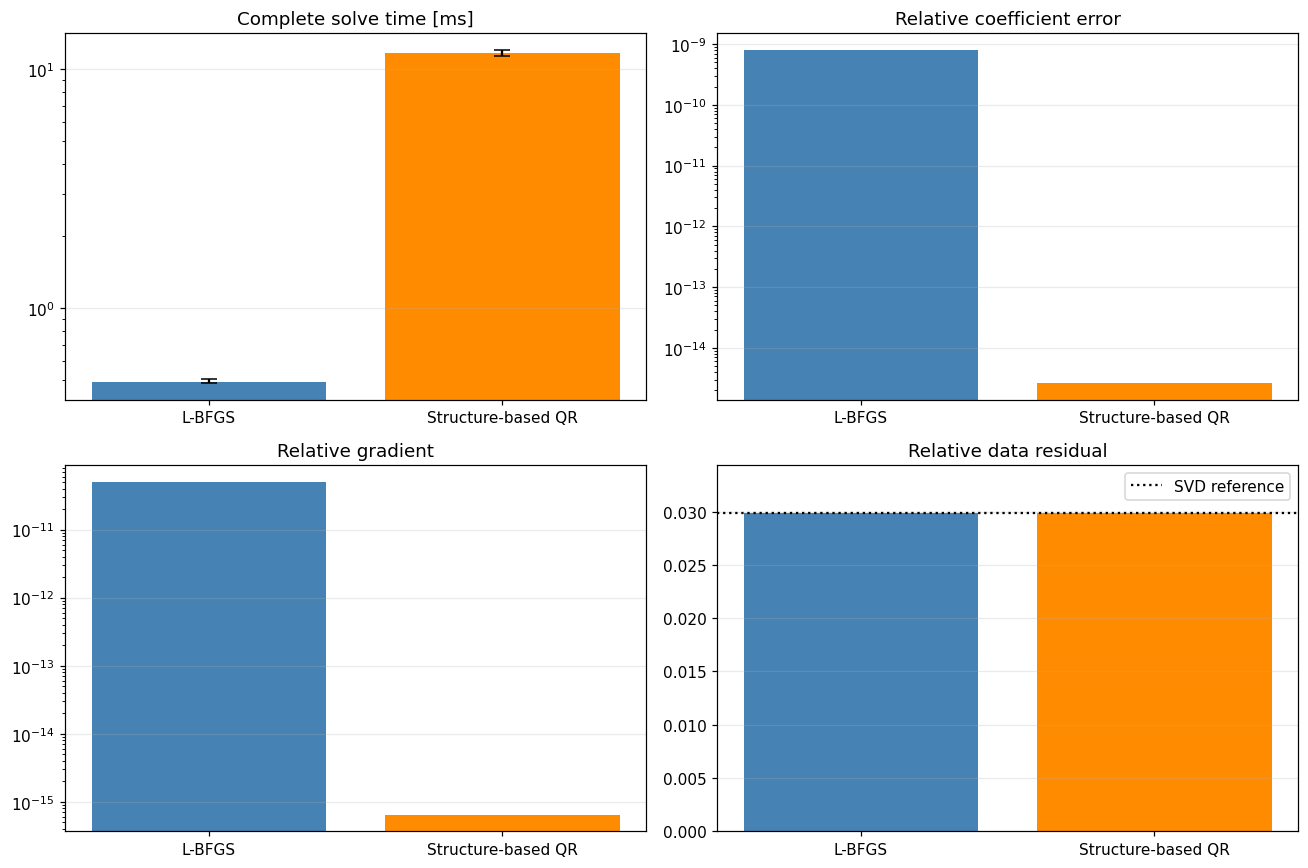

In [96]:
# Keep runtime and accuracy metrics on separate axes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
positions = np.arange(len(METHODS))
ordered = svd_baseline_df.set_index('method').loc[list(METHODS)]
panels = [
    ('time_ms', 'Complete solve time [ms]'),
    ('w_error', 'Relative coefficient error'),
    ('grad_relative', 'Relative gradient'),
    ('data_residual', 'Relative data residual'),
]
for ax, (column, title) in zip(axes.flat, panels):
    ax.bar(positions, positive(ordered[column]), color=[COLORS[method] for method in METHODS])
    if column == 'time_ms':
        errors = np.vstack((ordered[column] - ordered['q25_ms'], ordered['q75_ms'] - ordered[column]))
        ax.errorbar(positions, ordered[column], yerr=errors, fmt='none', color='black', capsize=5)
    # Use a zero-based linear axis for nearly identical data residuals
    if column == 'data_residual':
        ax.axhline(svd_baseline_row[column], color='black', linestyle=':', label='SVD reference')
        ax.set_ylim(0, 1.15 * max(ordered[column].max(), svd_baseline_row[column]))
        ax.legend()
    else:
        ax.set_yscale('log')
    ax.set_xticks(positions, METHODS)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## 6. Iterative convergence versus direct-solver accuracy

For L-BFGS we track $\|g_k\|_2/\|g_0\|_2$ and
$\|w_k-w_{\mathrm{ref}}\|_2/\|w_{\mathrm{ref}}\|_2$. The QR result provides
a horizontal **final-accuracy reference**, not an iterative trajectory.
The requested L-BFGS gradient threshold is shown independently.

The diagnostic run below enables `w_star` solely to record distances; it is
excluded from the benchmark. The solver does not record per-iteration times,
so no artificial time axis is inferred from the iteration count. Actual
time–accuracy trade-offs are measured in the following experiment.

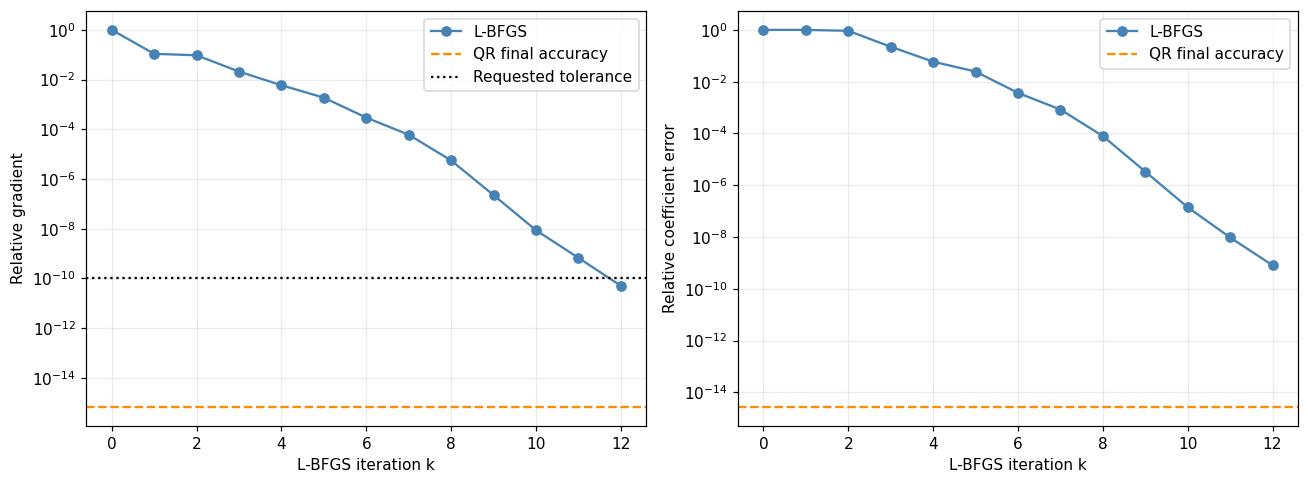

In [97]:
# Record iterate distances in a separate diagnostic run outside the benchmark
with blas_context():
    _, convergence_history, _ = lbfgs_optimize(
        X, y, LAMBDA, **LBFGS_OPTIONS, w_star=svd_baseline['w'],
    )
iterations = np.arange(len(convergence_history['f']))
gradient_curve = np.asarray(convergence_history['grad_norm']) / convergence_history['grad_norm'][0]
error_curve = np.asarray(convergence_history['dist_to_opt']) / svd_baseline['norm_w']
qr_baseline = baseline_by_method.loc['Structure-based QR']

# Use the final QR accuracy as a reference for the L-BFGS trajectory
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, curve, metric, label in zip(
    axes, (gradient_curve, error_curve), ('grad_relative', 'w_error'),
    ('Relative gradient', 'Relative coefficient error'),
):
    ax.semilogy(iterations, positive(curve), 'o-', color=COLORS['L-BFGS'], label='L-BFGS')
    ax.axhline(max(qr_baseline[metric], PLOT_FLOOR), color=COLORS['Structure-based QR'],
               linestyle='--', label='QR final accuracy')
    ax.set(xlabel='L-BFGS iteration k', ylabel=label)
    ax.grid(True, which='both', alpha=0.25)
axes[0].axhline(LBFGS_OPTIONS['tol'], color='black', linestyle=':', label='Requested tolerance')
for ax in axes:
    ax.legend()
fig.tight_layout()
plt.show()

## 7. Measured time–accuracy trade-off

We vary only the L-BFGS stopping tolerance,
$\varepsilon\in\{10^{-2},10^{-4},\ldots,10^{-14}\}$, and repeat each complete
solve. QR has no stopping tolerance and retains the same baseline measurement.
Tighter requested tolerances need not produce proportionally smaller errors:
finite precision and the implementation's early-stop conditions can intervene.
The next cell preserves the actual termination status for every tolerance.

In [98]:
# Repeat full L-BFGS solves while changing only the requested tolerance
tolerance_tables = []
for tolerance in TOLERANCES:
    table, _ = benchmark_pair(
        X, y, LAMBDA, baseline=svd_baseline,
        lbfgs_options={'tol': float(tolerance)}, methods=('L-BFGS',),
    )
    tolerance_tables.append(table)
# Combine the measured tolerances into one comparison table
tolerance_results = pd.concat(tolerance_tables, ignore_index=True)
display(tolerance_results[['requested_tol', 'time_ms', 'q25_ms', 'q75_ms', 'iterations', 'w_error', 'grad_relative', 'status']])

,requested_tol,time_ms,q25_ms,q75_ms,iterations,w_error,grad_relative,status
0,1.000e-02,1.312e-01,1.298e-01,1.746e-01,4,5.909e-02,5.927e-03,converged
1,1.000e-04,2.554e-01,2.515e-01,3.002e-01,7,8.390e-04,6.052e-05,converged
2,1.000e-06,3.193e-01,3.184e-01,3.219e-01,9,3.362e-06,2.252e-07,converged
3,1.000e-08,3.727e-01,3.677e-01,3.755e-01,10,1.409e-07,8.695e-09,converged
4,1.000e-10,4.966e-01,4.762e-01,5.122e-01,12,8.074e-10,5.059e-11,converged
5,1.000e-12,5.474e-01,5.424e-01,5.656e-01,14,6.496e-12,4.101e-13,converged
6,1.000e-14,7.237e-01,7.174e-01,7.361e-01,23,3.873e-12,2.359e-12,stopped_before_tol


### 7.1 Equal-accuracy comparison

Each point below is a separately timed full solve. Labels indicate the requested
tolerance; crosses identify L-BFGS runs that did not satisfy it. We then impose
the same observable quality requirements on both algorithms:
$$
e_w\leq\delta_w,\qquad g_{\mathrm{rel}}\leq\delta_g.
$$
The table selects the fastest **measured** L-BFGS configuration meeting these
targets and compares it with QR only if QR also meets them. The targets are
`TARGET_W_ERROR` and `TARGET_GRADIENT` in `lib/comparison.py`, with defaults
$\delta_w=10^{-6}$ and $\delta_g=10^{-8}$. This is a comparison among sampled
configurations, not a claim of globally optimal tuning. The selection uses
achieved accuracy even when a stricter requested stopping tolerance was missed.

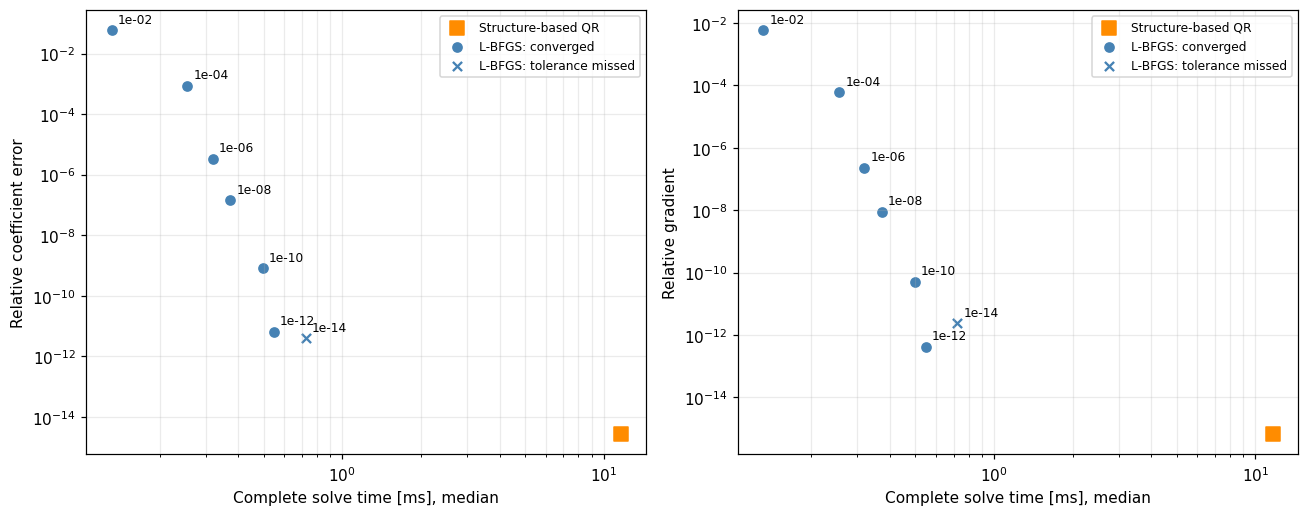

Common targets: coefficient error <= 1e-06, relative gradient <= 1e-08


,method,requested_tol,time_ms,w_error,grad_relative,status
0,L-BFGS,1.000e-08,3.727e-01,1.409e-07,8.695e-09,converged
1,Structure-based QR,NaN,1.164e+01,2.643e-15,6.490e-16,direct


In [99]:
# Plot each complete solve and distinguish missed tolerances with crosses
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, metric, label in zip(axes, ('w_error', 'grad_relative'), ('Relative coefficient error', 'Relative gradient')):
    for _, row in tolerance_results.iterrows():
        marker = 'o' if row['status'] == 'converged' else 'x'
        ax.scatter(row['time_ms'], max(row[metric], PLOT_FLOOR), marker=marker, color=COLORS['L-BFGS'])
        ax.annotate(f"{row['requested_tol']:.0e}", (row['time_ms'], max(row[metric], PLOT_FLOOR)),
                    xytext=(4, 5), textcoords='offset points', fontsize=8)
    ax.scatter(qr_baseline['time_ms'], max(qr_baseline[metric], PLOT_FLOOR),
               marker='s', s=80, color=COLORS['Structure-based QR'], label='Structure-based QR')
    ax.scatter([], [], color=COLORS['L-BFGS'], label='L-BFGS: converged')
    ax.scatter([], [], marker='x', color=COLORS['L-BFGS'], label='L-BFGS: tolerance missed')
    ax.set(xscale='log', yscale='log', xlabel='Complete solve time [ms], median', ylabel=label)
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Select configurations that satisfy both common accuracy targets
eligible_lbfgs = tolerance_results[
    (tolerance_results['w_error'] <= TARGET_W_ERROR)
    & (tolerance_results['grad_relative'] <= TARGET_GRADIENT)
]
quality_rows = []
if not eligible_lbfgs.empty:
    quality_rows.append(eligible_lbfgs.loc[eligible_lbfgs['time_ms'].idxmin()].to_dict())
if qr_baseline['w_error'] <= TARGET_W_ERROR and qr_baseline['grad_relative'] <= TARGET_GRADIENT:
    quality_rows.append({'method': 'Structure-based QR', **qr_baseline.to_dict()})
# Report the fastest qualifying L-BFGS run together with qualifying QR results
quality_results = pd.DataFrame(quality_rows)
print(f'Common targets: coefficient error <= {TARGET_W_ERROR:.0e}, relative gradient <= {TARGET_GRADIENT:.0e}')
if quality_results.empty:
    print('No measured configuration meets both targets.')
else:
    display(quality_results.reindex(columns=['method', 'requested_tol', 'time_ms',
                                            'w_error', 'grad_relative', 'status']))
for method in METHODS:
    if not any(row['method'] == method for row in quality_rows):
        print(f'{method}: no measured configuration meets both targets.')

## 8. Regularization, conditioning, and accuracy

We now vary $\lambda$ on the same $X,y$, keeping the L-BFGS settings fixed.
Changing $\lambda$ changes both the conditioning and the minimizer, so every
point uses its own SVD reference. Timings include a fresh QR factorization
at every $\lambda$; no factorization is reused.

An important feature of this problem is that $w_0=0$ and $Xy\in\operatorname{range}(X)$.
In exact arithmetic the L-BFGS iterates remain in this subspace. If $X$ has full
column rank and $m>n$, its relevant restricted Hessian condition number is
$$
\kappa(H|_{\operatorname{range}(X)})
=\frac{\sigma_{\max}^2+\lambda^2}{\sigma_{\min}^2+\lambda^2},
$$
whereas the full Hessian additionally has $m-n$ eigenvalues equal to
$\lambda^2$. Thus a large full condition number alone does not predict slow
convergence from zero. The following cell records both condition numbers,
as well as the optimality residual of each numerical SVD reference.

In [100]:
lambda_tables = []
singular_values = real_svd[1]
# Check full column rank before using the restricted condition formula
assert singular_values[-1] > np.finfo(float).eps * max(X.shape) * singular_values[0]
for lam_value in LAMBDAS:
    # Build the SVD baseline for the current regularization value
    svd_baseline = svd_solver_baseline(X, y, float(lam_value), factors=real_svd)
    table, _ = benchmark_pair(X, y, float(lam_value), baseline=svd_baseline)
    table['kappa_H'] = svd_baseline['kappa_H']
    table['kappa_range_H'] = ((singular_values[0]**2 + lam_value**2) / (singular_values[-1]**2 + lam_value**2))
    table['reference_grad_relative'] = solution_metrics(svd_baseline['w'], X, y, lam_value, svd_baseline)['grad_relative']
    lambda_tables.append(table)
# Collect timings and errors together with the conditioning information
lambda_results = pd.concat(lambda_tables, ignore_index=True)
display(lambda_results[['lambda', 'method', 'kappa_A', 'kappa_range_H', 'time_ms', 'iterations', 'w_error', 'grad_relative', 'status']])
print('Largest SVD reference relative gradient:', lambda_results['reference_grad_relative'].max())

,lambda,method,kappa_A,kappa_range_H,time_ms,iterations,w_error,grad_relative,status
0,1.000e-08,L-BFGS,7.575e+09,1.036e+03,4.885e-01,1.200e+01,1.117e-09,6.967e-11,converged
1,1.000e-08,Structure-based QR,7.575e+09,1.036e+03,1.168e+01,NaN,7.704e-08,5.594e-16,direct
2,1.000e-07,L-BFGS,7.575e+08,1.036e+03,4.796e-01,1.200e+01,1.117e-09,6.967e-11,converged
3,1.000e-07,Structure-based QR,7.575e+08,1.036e+03,1.119e+01,NaN,6.155e-09,5.629e-16,direct
4,1.000e-06,L-BFGS,7.575e+07,1.036e+03,4.918e-01,1.200e+01,1.117e-09,6.967e-11,converged
5,1.000e-06,Structure-based QR,7.575e+07,1.036e+03,1.142e+01,NaN,1.105e-09,6.890e-16,direct
6,1.000e-05,L-BFGS,7.575e+06,1.036e+03,4.855e-01,1.200e+01,1.117e-09,6.967e-11,converged
7,1.000e-05,Structure-based QR,7.575e+06,1.036e+03,1.123e+01,NaN,1.333e-10,1.187e-15,direct
8,1.000e-04,L-BFGS,7.575e+05,1.036e+03,4.776e-01,1.200e+01,1.117e-09,6.967e-11,converged
9,1.000e-04,Structure-based QR,7.575e+05,1.036e+03,1.117e+01,NaN,6.040e-12,1.520e-16,direct


Largest SVD reference relative gradient: 2.787362504713773e-15


### 8.1 Reading the regularization sweep

The four panels show runtime, coefficient error, relative gradient, and full
versus restricted Hessian conditioning. These views help distinguish loss of
forward accuracy from loss of optimality. QR avoids explicitly squaring the
condition number, but forward errors can still grow on ill-conditioned problems.
The curves describe this dataset and initialization; they are not universal
rankings of direct and iterative methods.

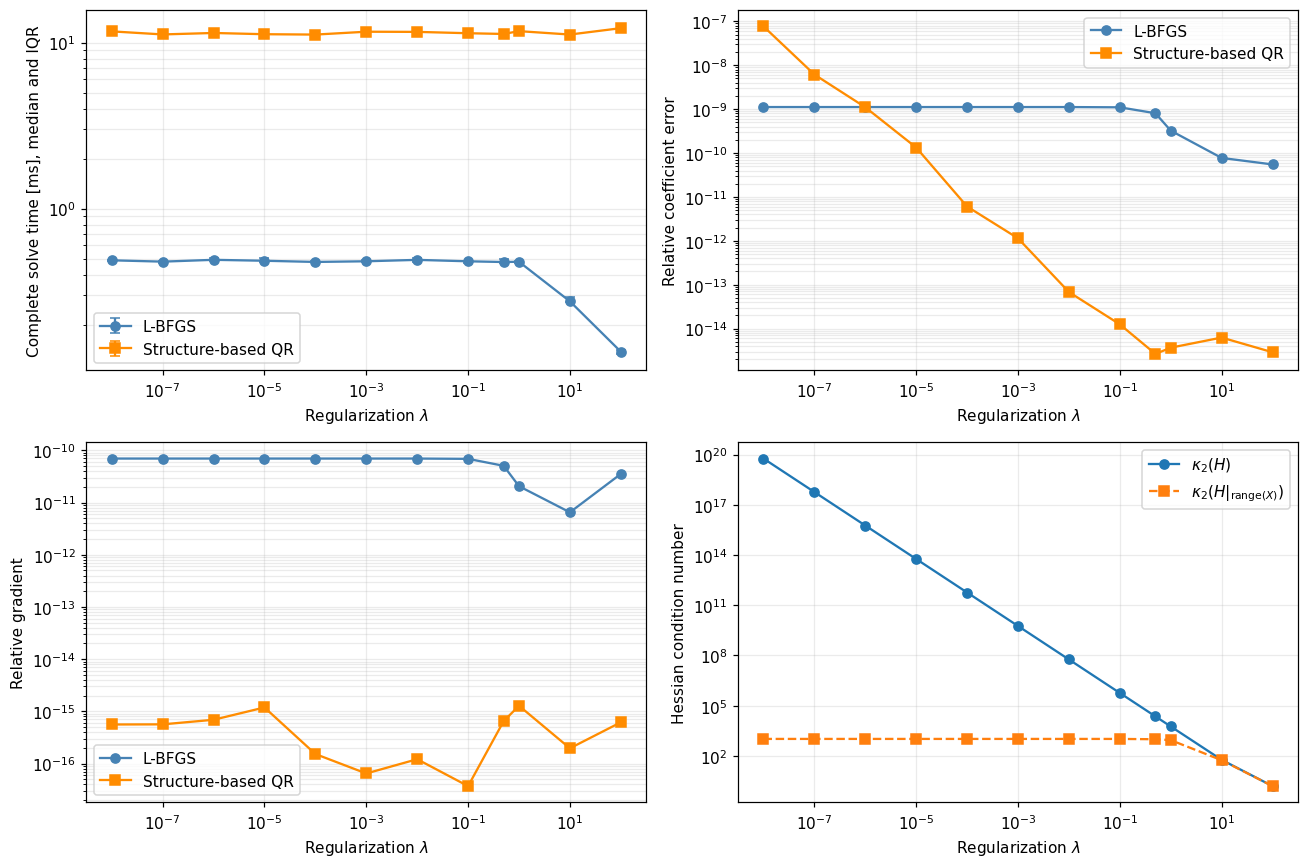

In [101]:
# Compare runtime and numerical accuracy across regularization values
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_time_iqr(axes[0, 0], lambda_results, 'lambda')
for method in METHODS:
    subset = lambda_results[lambda_results['method'] == method]
    for ax, metric, label in ((axes[0, 1], 'w_error', 'Relative coefficient error'), (axes[1, 0], 'grad_relative', 'Relative gradient')):
        ax.loglog(subset['lambda'], positive(subset[metric]), marker=MARKERS[method], color=COLORS[method], label=method)
        ax.set_ylabel(label)
        ax.legend()
# Separate full Hessian conditioning from conditioning on the range of X
condition_rows = lambda_results[lambda_results['method'] == 'L-BFGS']
axes[1, 1].loglog(condition_rows['lambda'], condition_rows['kappa_H'], 'o-', label=r'$\kappa_2(H)$')
axes[1, 1].loglog(condition_rows['lambda'], condition_rows['kappa_range_H'], 's--', label=r'$\kappa_2(H|_{\mathrm{range}(X)})$')
axes[1, 1].set_ylabel('Hessian condition number')
axes[1, 1].legend()
for ax in axes.flat:
    ax.set_xscale('log')
    ax.set_xlabel(r'Regularization $\lambda$')
    ax.grid(True, which='both', alpha=0.25)
fig.tight_layout()
plt.show()

## 9. Scaling with the number of unknowns $m$

For fixed $n$ and L-BFGS memory $h$, the leading computational costs are
$$
T_{\mathrm{L\text{-}BFGS}}=O\!\left(k(mn+hm)\right),
\qquad T_{\mathrm{QR}}=O\!\left((n+1)m^2\right).
$$
Here $k$ is the observed iteration count, not a constant guaranteed by the
algorithm. The current QR implementation stores a dense $m\times m$ factor.

The next cell creates a single enlarged ML-CUP matrix using the existing
row-resampling helper, then takes nested prefixes. Rows beyond the original
dataset are synthetic resamples with small jitter. We keep $n,y,\lambda$ fixed
and record conditioning and iteration counts because they can change with $m$.
Data construction and reference computation remain outside solver timings.

This follows notebook 03's resampling approach and uses the same default
maximum size of 4000, seed 42, and jitter 0.01. The tested dimensions are
defined by `M_SIZES` in `lib/comparison.py`. Notebook 02 instead uses
standardized Gaussian matrices for its dimension sweeps, so its iteration
counts are not a replication target for this experiment.


In [102]:
# Build one data pool so increasing dimensions use nested row prefixes
if int(M_SIZES.max()) > m:
    X_pool = build_augmented_X(X, m=int(M_SIZES.max()), seed=SEED, jitter=0.01)
else:
    X_pool = X.copy()

# Benchmark each number of unknowns with fixed data-equation count and regularization
m_tables = []
for m_size in M_SIZES:
    X_size = np.ascontiguousarray(X_pool[:int(m_size), :])
    table, _ = benchmark_pair(X_size, y, LAMBDA)
    m_tables.append(table)
m_results = pd.concat(m_tables, ignore_index=True)

display(m_results[['m', 'method', 'kappa_A', 'time_ms', 'q25_ms', 'q75_ms', 'iterations', 'w_error', 'grad_relative', 'status']])

,m,method,kappa_A,time_ms,q25_ms,q75_ms,iterations,w_error,grad_relative,status
0,100,L-BFGS,7.021e+01,4.481e-01,4.235e-01,4.810e-01,1.200e+01,6.931e-15,3.478e-13,converged
1,100,Structure-based QR,7.021e+01,1.878e+00,1.851e+00,2.131e+00,NaN,2.516e-15,5.682e-16,direct
2,250,L-BFGS,1.071e+02,4.743e-01,4.669e-01,4.764e-01,1.200e+01,3.028e-10,1.905e-11,converged
3,250,Structure-based QR,1.071e+02,5.009e+00,4.980e+00,5.053e+00,NaN,1.958e-15,5.249e-16,direct
4,500,L-BFGS,1.515e+02,5.508e-01,5.429e-01,5.535e-01,1.200e+01,8.074e-10,5.059e-11,converged
5,500,Structure-based QR,1.515e+02,1.200e+01,1.175e+01,1.237e+01,NaN,2.643e-15,1.719e-15,direct
6,1000,L-BFGS,2.127e+02,7.632e-01,7.446e-01,8.274e-01,1.200e+01,7.022e-10,4.851e-11,converged
7,1000,Structure-based QR,2.127e+02,3.120e+01,3.044e+01,3.129e+01,NaN,4.346e-15,5.658e-16,direct
8,2000,L-BFGS,3.020e+02,1.086e+00,1.058e+00,1.117e+00,1.200e+01,7.019e-10,4.887e-11,converged
9,2000,Structure-based QR,3.020e+02,8.543e+01,8.299e+01,8.630e+01,NaN,5.434e-15,6.397e-16,direct


### 9.1 Runtime growth must be read together with accuracy

The dashed $O(m)$ and $O(m^2)$ curves are visual guides normalized at the first
measured size; they are not fitted complexity proofs. Linear L-BFGS growth is
expected only when its iteration count remains comparable. The other panels
show achieved accuracy and $k$, so a faster run that misses its tolerance is
visible in the table rather than being treated as a successful solve.

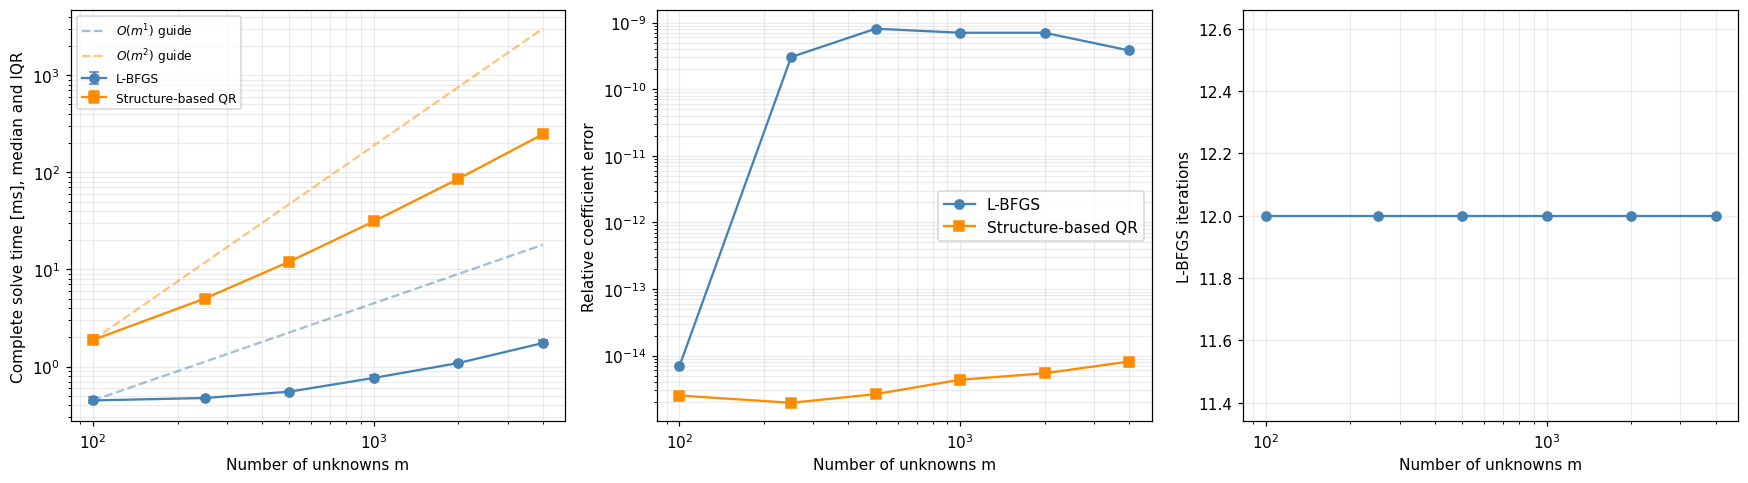

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_time_iqr(axes[0], m_results, 'm')
# Anchor linear and quadratic runtime guides at the smallest measured size
for method, exponent in zip(METHODS, (1, 2)):
    subset = m_results[m_results['method'] == method].sort_values('m')
    guide = subset['time_ms'].iloc[0] * (subset['m'] / subset['m'].iloc[0])**exponent
    axes[0].plot(subset['m'], guide, '--', color=COLORS[method], alpha=0.5, label=fr'$O(m^{exponent})$ guide')
    axes[1].loglog(subset['m'], positive(subset['w_error']), marker=MARKERS[method], color=COLORS[method], label=method)
# Check whether the L-BFGS iteration count changes with the number of unknowns
lbfgs_m = m_results[m_results['method'] == 'L-BFGS']
axes[2].plot(lbfgs_m['m'], lbfgs_m['iterations'], 'o-', color=COLORS['L-BFGS'])
axes[0].legend(fontsize=8)
axes[1].set_ylabel('Relative coefficient error')
axes[1].legend()
axes[2].set_ylabel('L-BFGS iterations')
for ax in axes:
    ax.set(xscale='log', xlabel='Number of unknowns m')
    ax.grid(True, which='both', alpha=0.25)
fig.tight_layout()
plt.show()

## 10. Scaling with $n$ at controlled conditioning

To change $n$ without adding arbitrary features to the real dataset, construct
$$
X_n=U_n\Sigma_nV_n^T,\qquad U_n^TU_n=I_n,\quad V_n^TV_n=I_n,
$$
using random orthonormal factors and singular values geometrically spaced from
$10$ to $1$. We fix $m=500>n$ and use the shared $\lambda$ (default $0.5$), so both the full condition
number and the extremal restricted condition number stay constant as $n$
varies. The number of spectral directions still changes, which can affect
L-BFGS iterations. Each $n$ uses a deterministic synthetic right-hand side.

The following cell uses the imported `make_spectral_problem` to construct
each instance, calls `benchmark_pair`, then shows runtime,
forward error, and iteration count. Each point is one problem instance;
timing repetitions measure runtime variability, not variability over datasets.

Notebook 02's $n$ sweep also increases the history capacity to $h=n+15$ on
Gaussian matrices. Here $h=10$ stays fixed while the spectrum is prescribed.
Increasing $n$ therefore adds curvature directions without adding memory;
iteration growth can differ substantially even when both implementations agree.


,n,method,kappa_A,time_ms,iterations,w_error,grad_relative,status
0,4,L-BFGS,2.002e+01,1.529e-01,4.000e+00,1.710e-15,9.590e-15,converged
1,4,Structure-based QR,2.002e+01,1.012e+01,NaN,2.192e-15,1.820e-15,direct
2,8,L-BFGS,2.002e+01,3.301e-01,8.000e+00,1.223e-15,8.188e-16,converged
3,8,Structure-based QR,2.002e+01,1.081e+01,NaN,2.095e-15,7.266e-16,direct
4,12,L-BFGS,2.002e+01,5.636e-01,1.200e+01,6.145e-15,1.466e-14,converged
5,12,Structure-based QR,2.002e+01,1.160e+01,NaN,5.331e-15,7.183e-16,direct
6,24,L-BFGS,2.002e+01,1.620e+00,3.200e+01,5.255e-12,2.030e-11,converged
7,24,Structure-based QR,2.002e+01,1.575e+01,NaN,3.052e-15,9.712e-16,direct
8,48,L-BFGS,2.002e+01,1.162e+01,2.740e+02,6.591e-10,9.916e-11,converged
9,48,Structure-based QR,2.002e+01,1.974e+01,NaN,3.589e-15,8.560e-16,direct


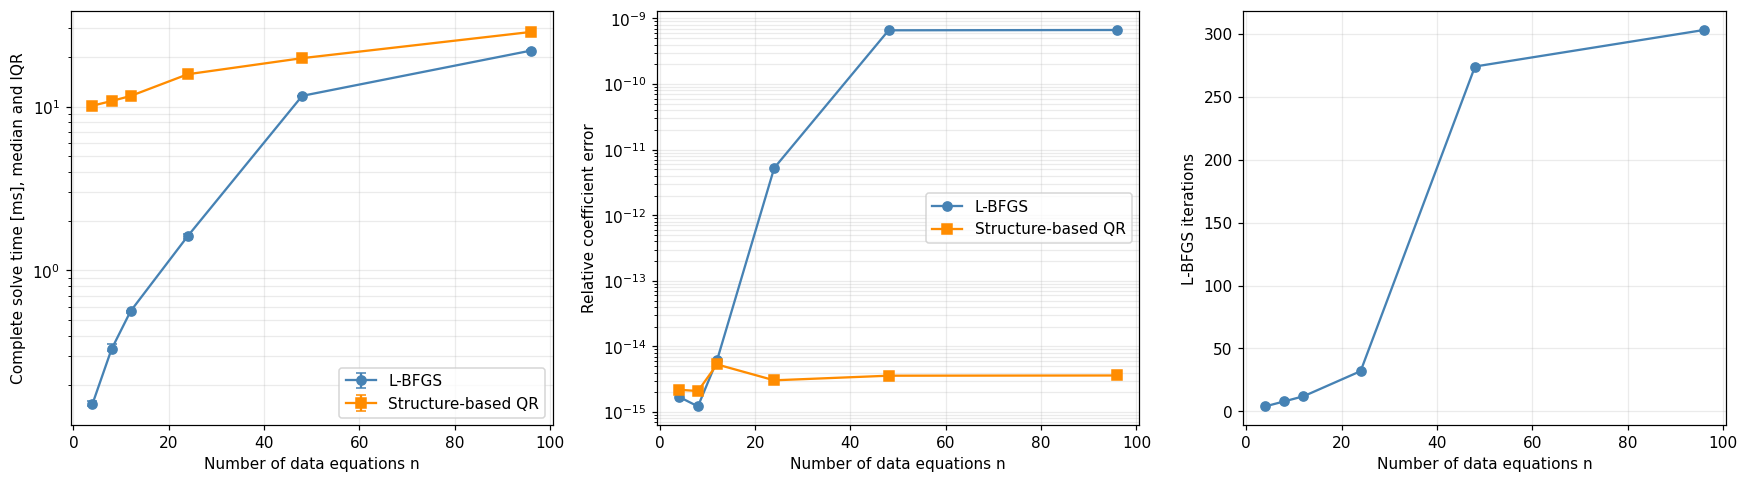

In [104]:
# Vary the number of spectral directions while keeping extremal conditioning fixed
n_tables = []
for n_size in N_SIZES:
    X_n, y_n = make_spectral_problem(500, int(n_size), seed=SEED + int(n_size))
    table, _ = benchmark_pair(X_n, y_n, LAMBDA)
    n_tables.append(table)
n_results = pd.concat(n_tables, ignore_index=True)
display(n_results[['n', 'method', 'kappa_A', 'time_ms', 'iterations', 'w_error', 'grad_relative', 'status']])

# Relate runtime and coefficient error to the observed iteration growth
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_time_iqr(axes[0], n_results, 'n')
for method in METHODS:
    subset = n_results[n_results['method'] == method]
    axes[1].semilogy(subset['n'], positive(subset['w_error']), marker=MARKERS[method], color=COLORS[method], label=method)
lbfgs_n = n_results[n_results['method'] == 'L-BFGS']
axes[2].plot(lbfgs_n['n'], lbfgs_n['iterations'], 'o-', color=COLORS['L-BFGS'])
axes[1].set_ylabel('Relative coefficient error')
axes[1].legend()
axes[2].set_ylabel('L-BFGS iterations')
for ax in axes:
    ax.set_xlabel('Number of data equations n')
    ax.grid(True, which='both', alpha=0.25)
fig.tight_layout()
plt.show()

## 11. Controlled ill-conditioned stress test

The real dataset alone may favor a particular method. We therefore use a
second family with $m=160$, $n=24$, and nonzero singular values geometrically
spaced from $1$ to $10^{-4}$. The same synthetic $X,y$ are solved at
$\lambda\in\{10^{-4},10^{-2},1\}$.

For small $\lambda$, even the restriction of $H$ to $\operatorname{range}(X)$
is ill-conditioned. This tests L-BFGS beyond the favorable spectral structure
of the real dataset. Its memory and iteration budget remain unchanged; a
budget-limited answer is displayed with a cross and explicitly reported.
The next cell repeats the timing protocol and compares errors against a fresh
SVD reference for each regularization value.

,lambda,method,kappa_A,time_ms,iterations,w_error,grad_relative,status
0,1.000e-04,L-BFGS,1.000e+04,6.312e+01,2.000e+03,2.166e-03,1.388e-06,max_iter
1,1.000e-04,Structure-based QR,1.000e+04,3.463e+00,NaN,3.954e-13,8.956e-14,direct
2,1.000e-02,L-BFGS,1.000e+02,4.542e+01,2.000e+03,4.242e-06,6.566e-08,max_iter
3,1.000e-02,Structure-based QR,1.000e+02,3.379e+00,NaN,1.701e-14,1.168e-15,direct
4,1.000e+00,L-BFGS,1.414e+00,2.522e-01,8.000e+00,1.950e-11,1.367e-11,converged
5,1.000e+00,Structure-based QR,1.414e+00,3.293e+00,NaN,4.564e-15,5.724e-16,direct


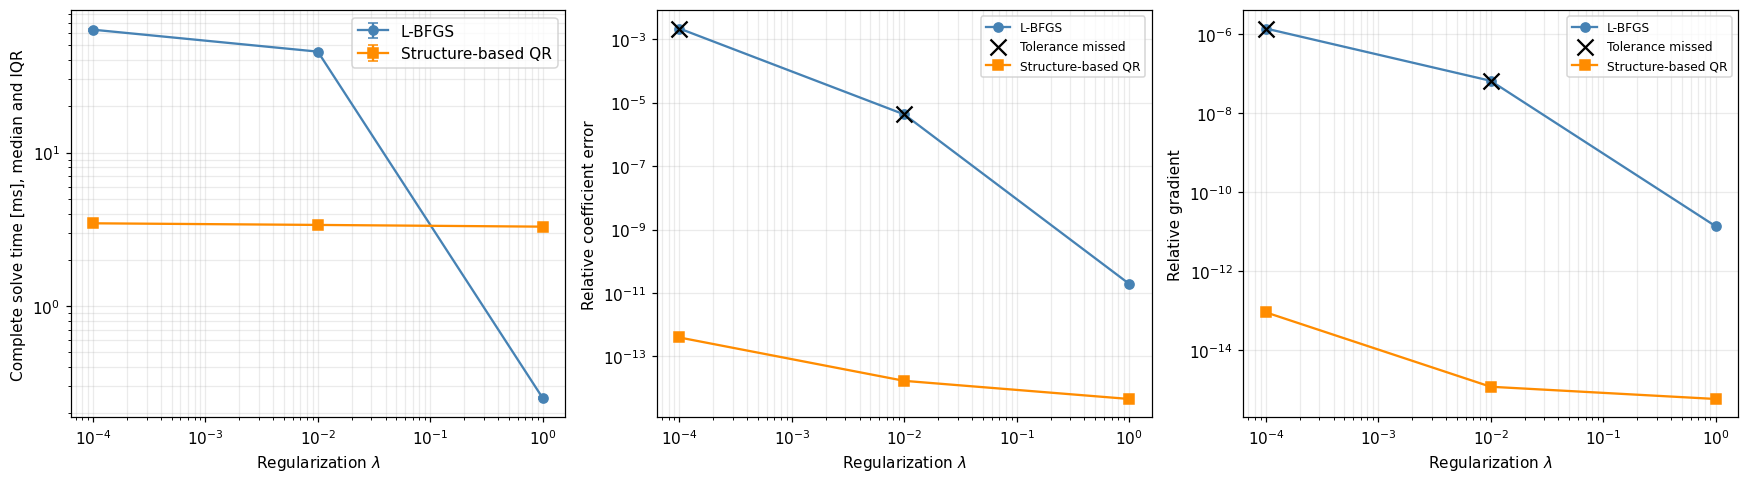

In [105]:
# Construct one difficult spectrum shared by all stress-test regularization values
X_stress, y_stress = make_spectral_problem(160, 24, sigma_min=1e-4, sigma_max=1.0)
stress_tables = []
for lam_value in (1e-4, 1e-2, 1.0):
    table, _ = benchmark_pair(X_stress, y_stress, lam_value)
    stress_tables.append(table)
stress_results = pd.concat(stress_tables, ignore_index=True)
display(stress_results[['lambda', 'method', 'kappa_A', 'time_ms', 'iterations', 'w_error', 'grad_relative', 'status']])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_time_iqr(axes[0], stress_results, 'lambda')
for method in METHODS:
    subset = stress_results[stress_results['method'] == method]
    for ax, metric in zip(axes[1:], ('w_error', 'grad_relative')):
        ax.loglog(subset['lambda'], positive(subset[metric]), marker=MARKERS[method], color=COLORS[method], label=method)
        # Highlight returned solutions that did not meet the requested tolerance
        failed = subset[~subset['status'].isin(['converged', 'direct'])]
        ax.scatter(
            failed['lambda'], positive(failed[metric]), marker='x', s=110,
            color='black', zorder=5, label='Tolerance missed' if not failed.empty else None
        )
        ax.legend(fontsize=8)
axes[1].set_ylabel('Relative coefficient error')
axes[2].set_ylabel('Relative gradient')
for ax in axes:
    ax.set(xscale='log', xlabel=r'Regularization $\lambda$')
    ax.grid(True, which='both', alpha=0.25)
fig.tight_layout()
plt.show()

## 12. Computational cost and principal storage

Let $k$ be the number of L-BFGS iterations and $h$ its history capacity.
With exact line search, objective/gradient evaluation and line search use
matrix–vector products; the two-loop recursion uses the stored vector pairs.

| Method | Work for one complete solve | Additional working storage, excluding shared inputs |
|---|---|---|
| L-BFGS | $O(k(mn+hm))$ | $O(hm+m+n+k)$, including the scalar convergence history |
| Structure-based QR | $O((n+1)m^2)$ | $O(m^2+mn)$ |

For a transparent numerical comparison, the next cell counts only the
**principal stored arrays** in `float64`:
$$
B_{\mathrm{pairs}}=8(2hm),\qquad
B_{R,\mathrm{reflectors}}=8\bigl(m^2+m(n+1)\bigr)\quad\text{bytes}.
$$
L-BFGS may store fewer than $h$ pairs; its curve is the configured pair capacity.
QR stores a full dense array for $R$, even though it is triangular.
These counts exclude inputs, temporary arrays, Python objects, and histories:
they are **not measured peak RAM**. The shared input matrix alone uses $8mn$
bytes. The plot uses MiB ($2^{20}$ bytes), and the table also relates actual
timings and iteration counts from the $m$ sweep.

,m,input_X_MiB,LBFGS_pair_capacity_MiB,QR_R_and_reflectors_MiB,QR_over_LBFGS_time,LBFGS_iterations
0,100,9.155e-03,1.526e-02,8.621e-02,4.191e+00,1.200e+01
1,250,2.289e-02,3.815e-02,5.016e-01,1.056e+01,1.200e+01
2,500,4.578e-02,7.629e-02,1.957e+00,2.178e+01,1.200e+01
3,1000,9.155e-02,1.526e-01,7.729e+00,4.089e+01,1.200e+01
4,2000,1.831e-01,3.052e-01,3.072e+01,7.870e+01,1.200e+01
5,4000,3.662e-01,6.104e-01,1.225e+02,1.409e+02,1.200e+01


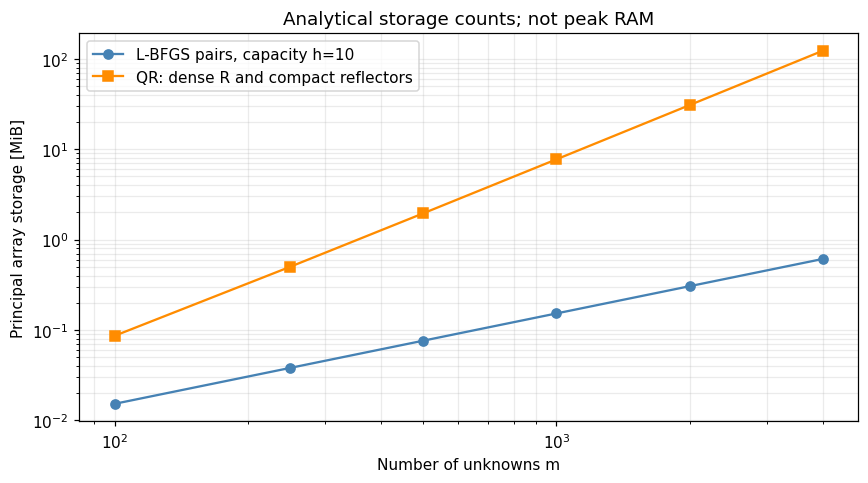

In [106]:
# Count the principal float64 arrays without claiming to measure peak memory
history_capacity = LBFGS_OPTIONS['m_history']
storage_sizes = M_SIZES.astype(float)
storage_table = pd.DataFrame({
    'm': M_SIZES,
    'input_X_MiB': 8 * storage_sizes * n / 2**20,
    'LBFGS_pair_capacity_MiB': 8 * 2 * history_capacity * storage_sizes / 2**20,
    'QR_R_and_reflectors_MiB': 8 * (storage_sizes**2 + storage_sizes * (n + 1)) / 2**20,
})
# Combine analytical storage counts with measured runtime ratios
timing_pivot = m_results.pivot(index='m', columns='method', values='time_ms')
storage_table['QR_over_LBFGS_time'] = (
    timing_pivot.loc[M_SIZES, 'Structure-based QR'].to_numpy()
    / timing_pivot.loc[M_SIZES, 'L-BFGS'].to_numpy()
)
storage_table['LBFGS_iterations'] = lbfgs_m.set_index('m').loc[M_SIZES, 'iterations'].to_numpy()
display(storage_table)

# Compare L-BFGS pair capacity with the QR factor and reflector storage
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(
    storage_table['m'], storage_table['LBFGS_pair_capacity_MiB'], 'o-',
    color=COLORS['L-BFGS'], label=f'L-BFGS pairs, capacity h={history_capacity}'
)
ax.loglog(
    storage_table['m'], storage_table['QR_R_and_reflectors_MiB'], 's-',
    color=COLORS['Structure-based QR'], label='QR: dense R and compact reflectors'
)
ax.set(xlabel='Number of unknowns m', ylabel='Principal array storage [MiB]', title='Analytical storage counts; not peak RAM')
ax.grid(True, which='both', alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## 13. Results and interpretation

The following code cell computes a numerical summary from the current run.
It also lists every measured
L-BFGS configuration that missed its requested tolerance. Conclusions should
be supported by all three aspects: runtime, achieved numerical accuracy, and
termination status.

When using these results in the report:

- Compare timings at the common accuracy targets, and state the L-BFGS memory,
  tolerance, iteration budget, and initialization.
- Use both coefficient error and optimality residual to assess small-$\lambda$
  behavior. Agreement in objective values alone can hide coefficient errors.
- Relate dimensional scaling to the observed iteration counts and conditioning;
  a guide line on a finite range does not establish an asymptotic law.
- Contrast the real-data experiment with the controlled-spectrum stress test.
  A missed tolerance is a result about this implementation and configuration,
  not a proof that L-BFGS cannot solve that problem.
- Treat SVD as a numerical reference, IQR as timing dispersion, and the storage
  model as array accounting. These experiments do not measure predictive
  generalization or process peak memory.

In [107]:
# Summarize baseline runtime and achieved numerical accuracy
for method in METHODS:
    row = baseline_by_method.loc[method]
    print(
        f"{method}: {row['time_ms']:.3f} ms, coefficient error {row['w_error']:.3e}, "
        f"relative gradient {row['grad_relative']:.3e}, status={row['status']}."
    )

if len(quality_results) == len(METHODS):
    matched = quality_results.set_index('method')
    matched_ratio = matched.loc['Structure-based QR', 'time_ms'] / matched.loc['L-BFGS', 'time_ms']
    print(f'At the common accuracy targets, measured QR / L-BFGS time = {matched_ratio:.2f}.')

# Gather benchmark tables using the experiment names as labels
experiment_tables = {
    'baseline': svd_baseline_df,
    'tolerance': tolerance_results,
    'regularization': lambda_results,
    'm_scaling': m_results,
    'n_scaling': n_results,
    'spectral_stress': stress_results,
}
all_results = pd.concat(
    [table.assign(experiment=name) for name, table in experiment_tables.items()],
    ignore_index=True,
)
# List L-BFGS runs that stopped without satisfying their requested tolerance
unsatisfied = all_results[(all_results['method'] == 'L-BFGS') & (all_results['status'] != 'converged')]
print(f'{len(unsatisfied)} L-BFGS configurations did not satisfy their requested tolerance.')
if not unsatisfied.empty:
    display(unsatisfied[['experiment', 'm', 'n', 'lambda', 'requested_tol', 'iterations', 'w_error', 'grad_relative', 'status']])

# Basic consistency checks on the recorded experiment outputs
assert np.isfinite(all_results['time_ms']).all() and (all_results['time_ms'] > 0).all()
assert (all_results['q25_ms'] <= all_results['time_ms']).all()
assert (all_results['time_ms'] <= all_results['q75_ms']).all()
assert np.isfinite(all_results[accuracy_columns].to_numpy()).all()

L-BFGS: 0.490 ms, coefficient error 8.074e-10, relative gradient 5.059e-11, status=converged.
Structure-based QR: 11.639 ms, coefficient error 2.643e-15, relative gradient 6.490e-16, status=direct.
At the common accuracy targets, measured QR / L-BFGS time = 31.23.
3 L-BFGS configurations did not satisfy their requested tolerance.


,experiment,m,n,lambda,requested_tol,iterations,w_error,grad_relative,status
8,tolerance,500,12,5.000e-01,1.000e-14,2.300e+01,3.873e-12,2.359e-12,stopped_before_tol
57,spectral_stress,160,24,1.000e-04,1.000e-10,2.000e+03,2.166e-03,1.388e-06,max_iter
59,spectral_stress,160,24,1.000e-02,1.000e-10,2.000e+03,4.242e-06,6.566e-08,max_iter


## 14. Conclusions

For the recorded experiments and solver settings:

- **Speed and scaling:** L-BFGS is faster on ML-CUP and its $m$ sweep, with lower principal storage requirements
- **Baseline accuracy:** QR reaches coefficient errors near $10^{-15}$, versus about $10^{-9}$ for L-BFGS at the default tolerance
- **Increasing $n$:** L-BFGS remains faster in the tested range, but its advantage shrinks as more iterations are needed with fixed memory
- **Difficult synthetic spectrum:** QR is faster and more accurate at $\lambda=10^{-4}$ and $10^{-2}$; L-BFGS exhausts its iteration budget
- **Very small $\lambda$ on ML-CUP:** QR can lose forward accuracy despite a tiny gradient, so neither method is uniformly best